In [1]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import string

# download required nltk data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("Ready!")

[nltk_data] Downloading package punkt to /home/syedtaha/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/syedtaha/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/syedtaha/nltk_data...


Ready!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
df = pd.read_csv('data/master_dataset.csv')
print(df.shape)
print(df['title'].head())

(173, 6)
0    Pashmina Shawl with Intricate Bird and Floral ...
1    Authentic kashmiri pashmina handmade tilla sha...
2    Hand Embroidered on pure Pashmina Shawl: Kashm...
3    Multi Embroidered Pashmina Shawl | Floral Aari...
4    Luxury Embroidered Pashmina Shawl, Ivory Kashm...
Name: title, dtype: str


In [3]:
# combine all titles into one big text
all_titles = ' '.join(df['title'].dropna().tolist()).lower()

# remove punctuation
all_titles = all_titles.translate(str.maketrans('', '', string.punctuation))

# tokenize — split into individual words
words = word_tokenize(all_titles)

# remove stopwords (common words like "the", "and", "for" that mean nothing)
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words and len(w) > 2]

# count most common words
word_freq = Counter(filtered_words)
print("Top 20 most common words in product titles:")
print(word_freq.most_common(20))

Top 20 most common words in product titles:
[('shawl', 183), ('pashmina', 170), ('kashmiri', 119), ('wrap', 99), ('scarf', 55), ('embroidered', 54), ('embroidery', 44), ('women', 44), ('soft', 34), ('kani', 33), ('winter', 33), ('luxury', 32), ('wool', 27), ('womens', 27), ('floral', 26), ('40x80', 23), ('inches', 22), ('large', 22), ('aari', 21), ('gift', 21)]


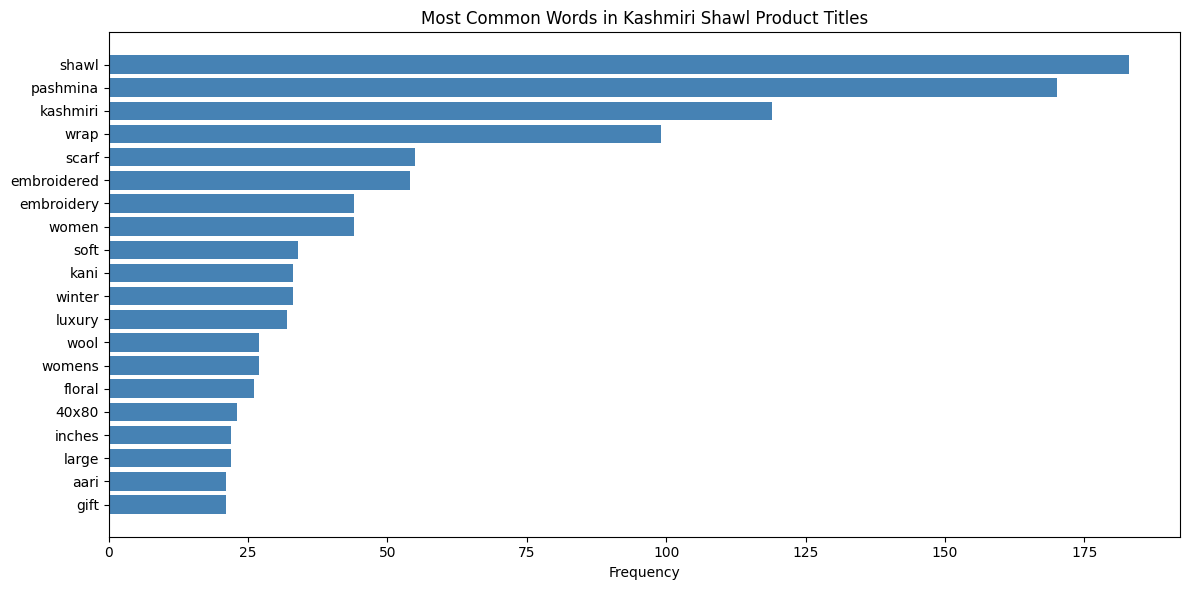

In [4]:
top_words = word_freq.most_common(20)
words_list = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(12, 6))
plt.barh(words_list[::-1], counts[::-1], color='steelblue')
plt.title('Most Common Words in Kashmiri Shawl Product Titles')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

In [5]:
# separate by platform
etsy_titles = ' '.join(df[df['source']=='Etsy']['title'].dropna().tolist()).lower()
amazon_titles = ' '.join(df[df['source']=='Amazon.ae']['title'].dropna().tolist()).lower()

# clean and count for etsy
etsy_words = [w for w in word_tokenize(etsy_titles.translate(str.maketrans('', '', string.punctuation))) 
              if w not in stop_words and len(w) > 2]
etsy_freq = Counter(etsy_words).most_common(10)

# clean and count for amazon
amazon_words = [w for w in word_tokenize(amazon_titles.translate(str.maketrans('', '', string.punctuation))) 
                if w not in stop_words and len(w) > 2]
amazon_freq = Counter(amazon_words).most_common(10)

print("Top 10 Etsy words:")
print(etsy_freq)
print("\nTop 10 Amazon.ae words:")
print(amazon_freq)

Top 10 Etsy words:
[('shawl', 136), ('pashmina', 124), ('kashmiri', 108), ('wrap', 80), ('embroidered', 54), ('embroidery', 40), ('kani', 32), ('luxury', 27), ('winter', 27), ('floral', 25)]

Top 10 Amazon.ae words:
[('shawl', 47), ('pashmina', 46), ('scarf', 31), ('women', 30), ('womens', 25), ('soft', 20), ('wrap', 19), ('wraps', 19), ('shawls', 16), ('evening', 14)]


In [6]:
etsy_set = set([w[0] for w in Counter(etsy_words).most_common(50)])
amazon_set = set([w[0] for w in Counter(amazon_words).most_common(50)])

print("Words unique to Etsy (not in Amazon top 50):")
print(etsy_set - amazon_set)

print("\nWords unique to Amazon (not in Etsy top 50):")
print(amazon_set - etsy_set)

Words unique to Etsy (not in Amazon top 50):
{'handmade', '40x80', 'blue', 'black', 'pure', 'sozni', 'embroidered', 'quality', 'fine', 'floral', 'authentic', 'grey', 'christmas', '100', 'white', 'needlework', 'ethnic', 'ivory', 'artisan', 'handwoven', 'border', 'kani', 'pink', 'beige', 'weave', 'blend', 'elegant', 'hand', 'traditional'}

Words unique to Amazon (not in Etsy top 50):
{'womens', 'jacquard', 'oversized', 'woven', 'classic', 'men', 'blanket', 'wraps', 'reversible', 'size', 'gifts', 'jamawar', 'stole', 'bridesmaid', 'travel', 'silky', 'silk', 'shawls', '200x70', 'mughal', 'scarves', 'weight', 'faux', 'dress', 'style', 'feel', 'stoles', 'warm', 'fashion'}


In [7]:
# save word frequency data
etsy_df = pd.DataFrame(etsy_freq, columns=['word', 'count'])
etsy_df['platform'] = 'Etsy'

amazon_df = pd.DataFrame(amazon_freq, columns=['word', 'count'])
amazon_df['platform'] = 'Amazon.ae'

keywords_df = pd.concat([etsy_df, amazon_df], ignore_index=True)
keywords_df.to_csv('data/keyword_analysis.csv', index=False)
print("Saved!")

Saved!
